In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as opt
import math

In [2]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
dta = pd.read_csv("five_stocks.csv")

In [4]:
dta.head()

,Unnamed: 0,Date,Open_GOOGL,High_GOOGL,Low_GOOGL,Close_GOOGL,Volume_GOOGL,Open_NVDA,High_NVDA,Low_NVDA,...,Open_AAPL,High_AAPL,Low_AAPL,Close_AAPL,Volume_AAPL,Open_KO,High_KO,Low_KO,Close_KO,Volume_KO
0,0,1972-06-01 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.38,1.38,1.38,1.38,0.0
1,1,1972-06-02 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.37,1.37,1.37,1.37,0.0
2,2,1972-06-05 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.37,1.37,1.37,1.37,0.0
3,3,1972-06-06 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.36,1.36,1.36,1.36,0.0
4,4,1972-06-07 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.35,1.35,1.35,1.35,0.0


In [5]:
open_cols = [c for c in dta.columns if c.startswith('Open_')]
start_idx = dta[open_cols].notna().all(axis=1).idxmax()
df_filtered = dta.loc[start_idx:].reset_index(drop=True)

In [6]:
df_filtered.head()

,Unnamed: 0,Date,Open_GOOGL,High_GOOGL,Low_GOOGL,Close_GOOGL,Volume_GOOGL,Open_NVDA,High_NVDA,Low_NVDA,...,Open_AAPL,High_AAPL,Low_AAPL,Close_AAPL,Volume_AAPL,Open_KO,High_KO,Low_KO,Close_KO,Volume_KO
0,8141,2004-08-19 16:00:00,2.50,2.60,2.40,2.51,22353092.0,0.10,0.10,0.1,...,0.57,0.57,0.54,0.55,6945541.0,22.18,22.28,21.83,21.96,5256900.0
1,8142,2004-08-20 16:00:00,2.54,2.73,2.51,2.71,11429498.0,0.10,0.10,0.1,...,0.55,0.55,0.54,0.55,5656707.0,21.95,22.11,21.78,22.10,4802600.0
2,8143,2004-08-23 16:00:00,2.77,2.84,2.73,2.74,9140244.0,0.10,0.11,0.1,...,0.55,0.56,0.55,0.56,4547417.0,22.12,22.36,22.00,22.17,4384100.0
3,8144,2004-08-24 16:00:00,2.78,2.79,2.59,2.62,7632224.0,0.11,0.11,0.1,...,0.56,0.57,0.56,0.57,6680922.0,22.25,22.25,22.00,22.01,4849900.0
4,8145,2004-08-25 16:00:00,2.62,2.70,2.60,2.65,4599110.0,0.10,0.11,0.1,...,0.57,0.59,0.57,0.59,9032543.0,21.99,22.23,21.86,22.17,4867200.0


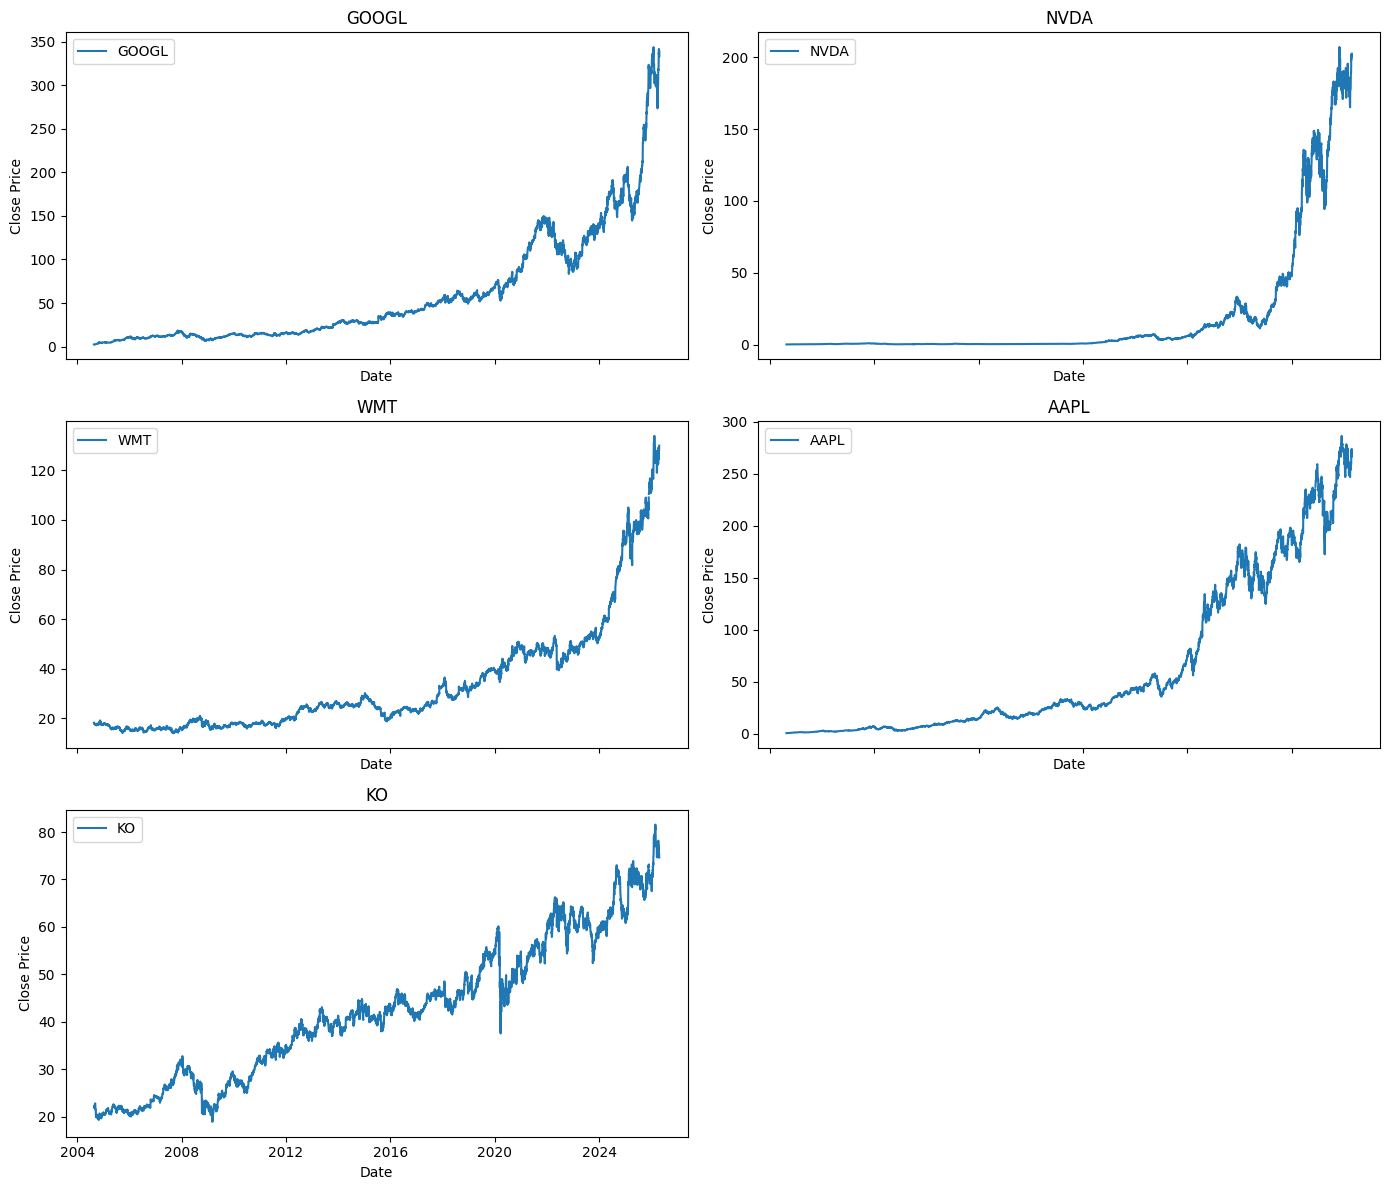

In [7]:
tickers = [c.replace('Close_', '') for c in df_filtered.columns if c.startswith('Close_')]
df_filtered['Date'] = pd.to_datetime(df_filtered['Date'])

ncols = 2
nrows = len(tickers) // ncols + (len(tickers) % ncols > 0)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
axes = axes.flatten()

for ax, t in zip(axes, tickers):
    ax.plot(df_filtered['Date'], df_filtered[f'Close_{t}'], label=t)
    ax.set_ylabel('Close Price')
    ax.set_xlabel("Date")
    ax.legend(loc='upper left')
    ax.set_title(t)

for ax in axes[len(tickers):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
close_cols = [f'Close_{t}' for t in tickers]
increments = df_filtered[close_cols].diff().dropna()
Sigma = increments.corr()
print(Sigma)

             Close_GOOGL  Close_NVDA  Close_WMT  Close_AAPL  Close_KO
Close_GOOGL     1.000000    0.367528   0.144689    0.495660  0.136635
Close_NVDA      0.367528    1.000000   0.025878    0.317963 -0.082830
Close_WMT       0.144689    0.025878   1.000000    0.241437  0.321602
Close_AAPL      0.495660    0.317963   0.241437    1.000000  0.227735
Close_KO        0.136635   -0.082830   0.321602    0.227735  1.000000


In [9]:
Sigma_tens = torch.tensor(Sigma.values,dtype=torch.float32)
Sigma_tilde = torch.linalg.cholesky(Sigma_tens)
d,_ = Sigma_tens.shape
idx = torch.tril_indices(d, d)
vech_sigma = Sigma_tens[idx[0], idx[1]]

In [10]:
print(Sigma_tens)
print(Sigma_tilde)

print(vech_sigma)

tensor([[ 1.0000,  0.3675,  0.1447,  0.4957,  0.1366],
        [ 0.3675,  1.0000,  0.0259,  0.3180, -0.0828],
        [ 0.1447,  0.0259,  1.0000,  0.2414,  0.3216],
        [ 0.4957,  0.3180,  0.2414,  1.0000,  0.2277],
        [ 0.1366, -0.0828,  0.3216,  0.2277,  1.0000]])
tensor([[ 1.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.3675,  0.9300,  0.0000,  0.0000,  0.0000],
        [ 0.1447, -0.0294,  0.9890,  0.0000,  0.0000],
        [ 0.4957,  0.1460,  0.1759,  0.8379,  0.0000],
        [ 0.1366, -0.1431,  0.3009,  0.1527,  0.9203]])
tensor([ 1.0000,  0.3675,  1.0000,  0.1447,  0.0259,  1.0000,  0.4957,  0.3180,
         0.2414,  1.0000,  0.1366, -0.0828,  0.3216,  0.2277,  1.0000])


In [11]:
def log_V(theta, X):
    """
    theta : (n, N-1, d)
    X : (n, N, d)
    """
    Delta_X = X[:, 1:, :] - X[:, :-1, :]
    inner = torch.sum(theta * Delta_X, dim=2)  # (n, N-1)
    return torch.sum(torch.log(1 + inner), dim=1)  # (n,)

def g(theta,X,T):
    return (1/T) * torch.mean(log_V(theta,X))

def UO(beta, sigma_tilde, N, T, n_paths=1, seed=0):
    torch.manual_seed(seed)
    d, _ = sigma_tilde.shape
    dt = T / N
    states = [torch.ones(size=(n_paths, d))]
    for t in range(N - 1):
        dW = math.sqrt(dt) * torch.randn(size=(n_paths, d))
        x_new = states[t] - (states[t] @ beta.T) * dt + (dW @ sigma_tilde.T)
        states.append(x_new)
    return torch.stack(states, dim=1)

In [12]:
class Loss_multi:
    def __init__(self, N, T, Sigma_tens, Sigma_tilde, lambda1,lambda2, n_paths=1, seed=0):
        self.N = N
        self.T = T
        self.lambda1 = lambda1
        self.lambda2 = lambda2

        self.Sigma_tilde = Sigma_tilde
        self.Sigma_tens = Sigma_tens
        self.n_paths = n_paths
        self.seed = seed

    def _simulate_and_act(self, f_agent, beta):
        X = UO(beta, self.Sigma_tilde, self.N, self.T, self.n_paths, seed=self.seed)
        d = X.shape[2]
        theta = f_agent(X[:, :-1, :].reshape(-1, d)).reshape(self.n_paths, self.N - 1, d)
        return theta, X

    def L_agent(self, f_agent, beta):
        theta, X = self._simulate_and_act(f_agent, beta)
        return -g(theta, X, self.T)

    def L_adv(self, f_agent, beta):
        theta, X = self._simulate_and_act(f_agent, beta)
        return g(theta, X, self.T) + self.lambda1 * torch.linalg.norm(self.Sigma_tens @ beta.T + beta @ self.Sigma_tens - self.Sigma_tens) ** 2
    
    
    # def L_adv(self, f_agent, beta):
    #     theta, X = self._simulate_and_act(f_agent, beta)
    #     lyap = torch.linalg.norm(self.Sigma_tens @ beta.T + beta @ self.Sigma_tens - self.Sigma_tens) ** 2
    #     eigvals = torch.linalg.eigvalsh(beta)
    #     stability = -torch.sum(torch.log(eigvals - 0.01))      
    #     return g(theta, X, self.T) + self.lambda1 * lyap + self.lambda2 * stability

In [13]:
class GradientAgent(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.phi = nn.Sequential(
            nn.Linear(d,d*5),
            nn.Tanh(),
            nn.Linear(5*d,math.ceil(0.5*d)),
            nn.Tanh(),
            nn.Linear(math.ceil(0.5*d), math.ceil(math.sqrt(d))),
            nn.Tanh(),
            nn.Linear(math.ceil(math.sqrt(d)), 1)
        )
    
    def forward(self, x):
        x = x.requires_grad_(True)
        phi = self.phi(x).sum()
        grad = torch.autograd.grad(phi, x, create_graph=True)[0]
        return grad

In [28]:
def nets():
    SEED = 0
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    f_agent = GradientAgent(d)

    # f_agent = nn.Sequential(
    #     nn.Linear(d,d*5),
    #     nn.ReLU(),
    #     nn.Linear(5*d,math.ceil(0.5*d)),
    #     nn.ReLU(),
    #     nn.Linear(math.ceil(0.5*d),math.ceil(math.sqrt(d))),
    #     nn.ReLU(),
    #     nn.Linear(math.ceil(math.sqrt(d)),d)
    # )

    # f_adv = nn.Sequential(
    #     nn.Linear(int((d*(d+1))/2),100*int((d*(d+1))/2)),
    #     nn.ReLU(),
    #     nn.Linear(100*int((d*(d+1))/2),d),
    #     nn.ReLU(),
    #     nn.Linear(d,math.ceil(0.5*d)),
    #     nn.ReLU(),
    #     nn.Linear(math.ceil(0.5*d),d**2)
    # )

    
    f_adv = nn.Sequential(
        nn.Linear(int((d*(d+1))/2),5*int((d*(d+1))/2)),
        nn.ReLU(),
        nn.Linear(5*int((d*(d+1))/2),d),
        nn.ReLU(),
        nn.Linear(d,math.ceil(0.5*d)),
        nn.ReLU(),
        nn.Linear(math.ceil(0.5*d),int((d*(d+1))/2))
    )

    
    print(f_agent)
    print(f_adv)
    return f_agent,f_adv


In [33]:
N = 100; n_paths = 1000; T = 1; seed=0; lambda1 = 0; lambda2=0
f_agent,f_adv = nets()


GradientAgent(
  (phi): Sequential(
    (0): Linear(in_features=5, out_features=25, bias=True)
    (1): Tanh()
    (2): Linear(in_features=25, out_features=3, bias=True)
    (3): Tanh()
    (4): Linear(in_features=3, out_features=3, bias=True)
    (5): Tanh()
    (6): Linear(in_features=3, out_features=1, bias=True)
  )
)
Sequential(
  (0): Linear(in_features=15, out_features=75, bias=True)
  (1): ReLU()
  (2): Linear(in_features=75, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=3, bias=True)
  (5): ReLU()
  (6): Linear(in_features=3, out_features=15, bias=True)
)


In [34]:
def make_beta_eigenbasis(raw_output, Sigma_tens, d, scale=0.01):
    eigvals_s, Q = torch.linalg.eigh(Sigma_tens)
    
    idx = torch.triu_indices(d, d, offset=1)
    raw = scale * raw_output[:idx[0].shape[0]]
    
    beta_prime = 0.5 * torch.eye(d)
    beta_prime[idx[0], idx[1]] = raw
    beta_prime[idx[1], idx[0]] = -raw * eigvals_s[idx[1]] / eigvals_s[idx[0]]
    
    return Q @ beta_prime @ Q.T

In [35]:
optimizer_agent = opt.SGD(f_agent.parameters(),lr=5e-3,momentum=0.9)    
optimizer_adv = opt.SGD(f_adv.parameters(),lr=1e-3)
epochs = 3000
L_coll = []
lyapunov_viol_coll = []
eigens = []


for ep in range(epochs):
    beta = make_beta_eigenbasis(f_adv(vech_sigma), Sigma_tens, d, scale=1)
    L = Loss_multi(N=N,T=T,Sigma_tens=Sigma_tens,Sigma_tilde=Sigma_tilde,lambda1=lambda1,lambda2=lambda2,n_paths=n_paths,seed=ep)

    optimizer_agent.zero_grad()
    loss_agent = L.L_agent(f_agent , beta)
    loss_agent.backward()
    optimizer_agent.step()

  
    beta = make_beta_eigenbasis(f_adv(vech_sigma), Sigma_tens, d, scale=1)

    optimizer_adv.zero_grad()
    loss_adv = L.L_adv(f_agent, beta)
    loss_adv.backward()
    optimizer_adv.step()

    L_coll.append(-loss_agent.item())
    # lyapunov_viol_coll.append(torch.linalg.norm(Sigma_tens @ beta.T + beta @ Sigma_tens - Sigma_tens).item())
    # eigens.append(torch.linalg.eigvalsh(beta).detach().numpy())

    if ep % (int(epochs / 10)) == 0:
        print(f"Progress: {ep}/{epochs}, g: {-loss_agent.item():.4f}")



Progress: 0/3000, g: -0.0009
Progress: 300/3000, g: 0.3332
Progress: 600/3000, g: 0.3793
Progress: 900/3000, g: 0.4615
Progress: 1200/3000, g: 0.4403
Progress: 1500/3000, g: 0.4354
Progress: 1800/3000, g: 0.4727
Progress: 2100/3000, g: 0.4205
Progress: 2400/3000, g: 0.4836
Progress: 2700/3000, g: 0.4314


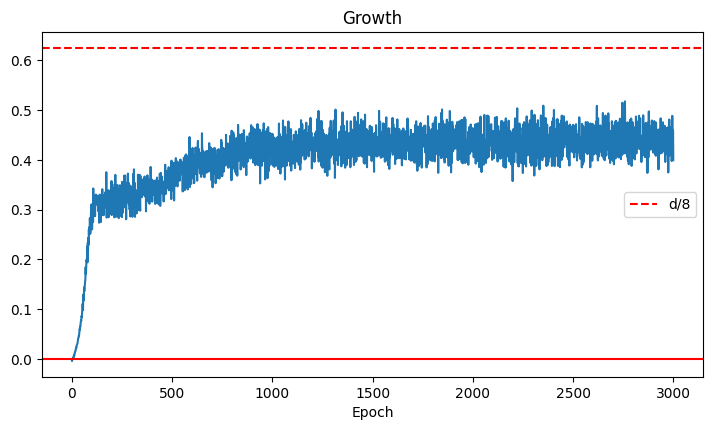

In [40]:
plt.figure(figsize=(14,8))
plt.subplot(2,2,1)
plt.plot(L_coll)
plt.axhline(y=d/8,color='red',linestyle="dashed",label="d/8")
plt.axhline(y=0,color='red')
plt.title("Growth")
plt.xlabel("Epoch")
plt.legend()


# plt.subplot(2,2,2)
# plt.plot(lyapunov_viol_coll)
# plt.yscale("log")
# plt.title("Lyapunov Violation")


# plt.subplot(2,2,3)
# plt.plot(min_eigvals)
# plt.axhline(y=0,color='red')
# plt.title("Smallest eigenvalue")

plt.tight_layout()
plt.show()

In [41]:
x = torch.randn(100, d, requires_grad=True)
theta = f_agent(x)
J = torch.zeros(100, d, d)
for i in range(d):
    grad_i = torch.autograd.grad(theta[:, i].sum(), x, retain_graph=True)[0]
    J[:, i, :] = grad_i
asymmetry = torch.norm(J - J.transpose(1, 2)) / torch.norm(J)
print(f"Jacobian asymmetry: {asymmetry.item():.4f}")

Jacobian asymmetry: 0.0000


In [42]:
beta_learned = make_beta_eigenbasis(f_adv(vech_sigma), Sigma_tens, d)
print("Learned beta:\n", beta_learned)
print("Difference from 0.5*I:\n", beta_learned - 0.5 * torch.eye(d))
print("Norm of difference:", torch.norm(beta_learned - 0.5 * torch.eye(d)).item())

Learned beta:
 tensor([[ 4.9921e-01, -5.7401e-03, -1.1778e-03,  5.6244e-03,  2.0788e-03],
        [ 6.6736e-03,  4.9721e-01,  7.6696e-03, -2.0348e-03, -9.5332e-03],
        [ 6.7864e-04, -4.6121e-03,  4.9811e-01, -2.7099e-04,  6.1337e-03],
        [-5.2520e-03,  1.5019e-03,  1.5214e-04,  5.0164e-01,  1.9656e-03],
        [-5.9324e-03,  9.3405e-03, -6.3336e-03, -9.1893e-04,  5.0383e-01]],
       grad_fn=<MmBackward0>)
Difference from 0.5*I:
 tensor([[-0.0008, -0.0057, -0.0012,  0.0056,  0.0021],
        [ 0.0067, -0.0028,  0.0077, -0.0020, -0.0095],
        [ 0.0007, -0.0046, -0.0019, -0.0003,  0.0061],
        [-0.0053,  0.0015,  0.0002,  0.0016,  0.0020],
        [-0.0059,  0.0093, -0.0063, -0.0009,  0.0038]], grad_fn=<SubBackward0>)
Norm of difference: 0.023549504578113556


C:\Users\trist\AppData\Local\Temp\ipykernel_41576\260118446.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([results_learned, results_analytical], labels=['Learned', 'Analytical'])


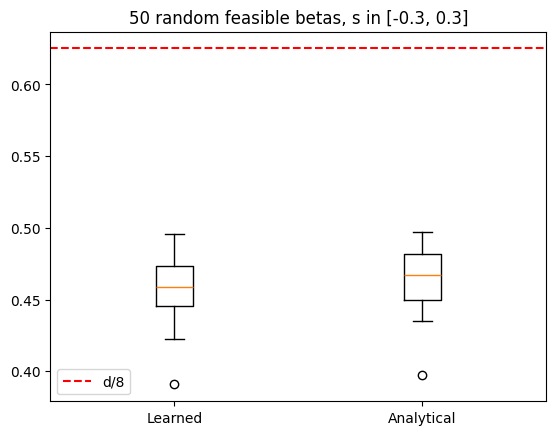

Learned:    mean=0.4552, std=0.0298
Analytical: mean=0.4615, std=0.0283


In [45]:

Sigma_inv = torch.linalg.inv(Sigma_tens)

# Different feasible betas: 0.5*I + S where S*Sigma is antisymmetric
def feasible_beta(Sigma_tens, s_values):
    d = Sigma_tens.shape[0]
    A = torch.zeros(d, d)
    idx = torch.triu_indices(d, d, offset=1)
    A[idx[0], idx[1]] = s_values
    A[idx[1], idx[0]] = -s_values
    S = A @ torch.linalg.inv(Sigma_tens)
    return 0.5 * torch.eye(d) + S


n_betas = 10
results_learned = []
results_analytical = []
N1=8000

for i in range(n_betas):
    s_values = 0.3 * (2 * torch.rand(d*(d-1)//2) - 1)  # random in [-0.3, 0.3]
    beta_i = feasible_beta(Sigma_tens, s_values)
    
    seed = 50000 + i
    X = UO(beta_i, Sigma_tilde, N=N1, T=T, n_paths=n_paths, seed=seed)
    
    theta_learned = f_agent(X[:, :-1, :].reshape(-1, d)).reshape(n_paths, N1-1, d)
    theta_analytical = -0.5 * (X[:, :-1, :] @ torch.linalg.inv(Sigma_tens).T)
    
    results_learned.append(g(theta_learned, X, T).item())
    results_analytical.append(g(theta_analytical, X, T).item())

plt.boxplot([results_learned, results_analytical], labels=['Learned', 'Analytical'])
plt.axhline(y=d/8, color='r', linestyle='--', label='d/8')
plt.title(f'50 random feasible betas, s in [-0.3, 0.3]')
plt.legend()
plt.show()

print(f"Learned:    mean={np.mean(results_learned):.4f}, std={np.std(results_learned):.4f}")
print(f"Analytical: mean={np.mean(results_analytical):.4f}, std={np.std(results_analytical):.4f}")
